David Alexandro Garcia Morales 31624

In [1]:
import numpy as np
import gzip
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
import seaborn as sns



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/alexgarcia/PycharmProjects/InteligenciaComputacional/.venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/alexgarcia/PycharmProjects/InteligenciaComputacional/.venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/alexgarcia/PycharmProjects/InteligenciaComputac

In [2]:
def load_mnist_dataset(mnist_path):
    x_trainval = get_images(Path(mnist_path)/Path('train-images-idx3-ubyte.gz'))
    y_trainval = get_labels(Path(mnist_path)/Path('train-labels-idx1-ubyte.gz'))

    x_train = x_trainval[:50000]
    y_train = y_trainval[:50000]

    x_val = x_trainval[50000:]
    y_val = y_trainval[50000:]

    x_test = get_images(Path(mnist_path)/Path('t10k-images-idx3-ubyte.gz'))
    y_test = get_labels(Path(mnist_path)/Path('t10k-labels-idx1-ubyte.gz'))

    return x_train, y_train, x_val, y_val, x_test, y_test

def get_labels(path):
    with gzip.open(path, 'rb') as data:
        labels = data.read()[8:]
        return np.frombuffer(labels, dtype=np.uint8)

def get_images(path):
    with gzip.open(path, 'rb') as data:
        _ = int.from_bytes(data.read(4), 'big')
        num_images = int.from_bytes(data.read(4), 'big')
        rows = int.from_bytes(data.read(4), 'big')
        cols = int.from_bytes(data.read(4), 'big')
        images = data.read()
        return np.frombuffer(images, dtype=np.uint8).reshape((num_images, rows, cols))


In [3]:
x_train, y_train, x_val, y_val, x_test, y_test = load_mnist_dataset('../data/mnist')

In [4]:
def plot_number(image):
    plt.figure(figsize=(5,5))
    plt.imshow(image.reshape((28,28)), cmap=plt.get_cmap('gray'))
    plt.axis('off')
    plt.show()

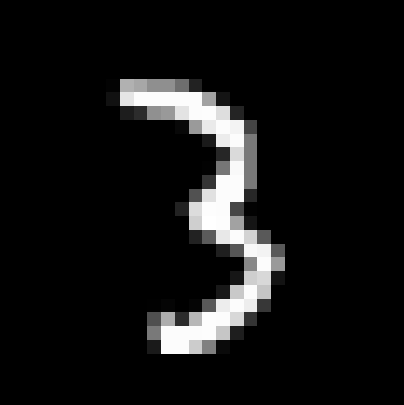

'Label: 3'

In [5]:
random_idx = np.random.randint(0, x_train.shape[0])
plot_number(x_train[random_idx])
display(f"Label: {y_train[random_idx].squeeze()}")

In [6]:
from torch.utils.data import Dataset, DataLoader, random_split
import torch

class MNISTDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32).unsqueeze(1) / 255.0
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

In [7]:
x_trainval = np.concatenate([x_train, x_val], axis=0)
y_trainval = np.concatenate([y_train, y_val], axis=0)

full_train = MNISTDataset(x_trainval, y_trainval)
test_ds    = MNISTDataset(x_test, y_test)

train_ds, val_ds = random_split(full_train, [50000, 10000])

print(f"Train:      {len(train_ds)}")
print(f"Validación: {len(val_ds)}")
print(f"Test:       {len(test_ds)}")

Train:      50000
Validación: 10000
Test:       10000


In [8]:
class MLP(nn.Module):
    def __init__(self, input_size: int, hidden_sizes: list, output_size: int):
        super().__init__()
        layers = []
        prev = input_size
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h
        layers.append(nn.Linear(prev, output_size))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)      # flatten: (batch, 1, 28, 28) → (batch, 784)
        x = (x - 0.1307) / 0.3081      # normalización estándar MNIST
        return self.net(x)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

Dispositivo: cpu


In [9]:
class EarlyStopping:
    def __init__(self, patience: int = 3, delta: float = 0.005):
        self.patience = patience
        self.delta    = delta
        self.history  = []

    def step(self, val_loss: float, epoch: int) -> bool:
        self.history.append(val_loss)
        if len(self.history) > self.patience:
            past = self.history[-(self.patience + 1)]
            curr = self.history[-1]
            if past >= curr and abs(past - curr) < self.delta:
                print(f"  *** Early stopping activado en época {epoch} ***")
                return True
        return False

    def reset(self):
        self.history = []

In [10]:
def train_model(model, train_loader, val_loader, optimizer, criterion,
                epochs, early_stopper=None, name="model"):
    model.to(device)
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):

        model.train()
        total_loss = 0.0
        pbar = tqdm(train_loader, desc=f"[{name}] Época {epoch}/{epochs}", leave=False)

        for X, y in pbar:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(X)
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        train_loss = total_loss / len(train_loader.dataset)

        model.eval()
        val_loss_total, correct = 0.0, 0

        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                logits = model(X)
                val_loss_total += criterion(logits, y).item() * len(X)
                correct += (logits.argmax(1) == y).sum().item()

        val_loss = val_loss_total / len(val_loader.dataset)
        val_acc  = correct / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"[{name}] Época {epoch:>3}/{epochs}"
              f"  Train Loss: {train_loss:.4f}"
              f"  Val Loss: {val_loss:.4f}"
              f"  Val Acc: {val_acc:.4f}")

        if early_stopper and early_stopper.step(val_loss, epoch):
            break

    return history

In [11]:
# Lógica de graficación de curvas fue dada por IA
def plot_history(history, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history["train_loss"]) + 1)

    ax1.plot(epochs, history["train_loss"], label="Train Loss", color="steelblue")
    ax1.plot(epochs, history["val_loss"],   label="Val Loss",   color="tomato")
    ax1.set_title("Pérdida por época")
    ax1.set_xlabel("Época"); ax1.set_ylabel("Loss")
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history["val_acc"], color="seagreen")
    ax2.set_title("Accuracy de Validación por época")
    ax2.set_xlabel("Época"); ax2.set_ylabel("Accuracy")
    ax2.grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

In [12]:
criterion = nn.CrossEntropyLoss()

Parámetros: 101,770
MLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


[Modelo1] Época   1/30  Train Loss: 0.2960  Val Loss: 0.1425  Val Acc: 0.9556


[Modelo1] Época   2/30  Train Loss: 0.1047  Val Loss: 0.1126  Val Acc: 0.9659


[Modelo1] Época   3/30  Train Loss: 0.0713  Val Loss: 0.1040  Val Acc: 0.9695


[Modelo1] Época   4/30  Train Loss: 0.0508  Val Loss: 0.0958  Val Acc: 0.9702


...

[Modelo1] Época  26/30  Train Loss: 0.0004  Val Loss: 0.1039  Val Acc: 0.9785


[Modelo1] Época  27/30  Train Loss: 0.0004  Val Loss: 0.1038  Val Acc: 0.9781


[Modelo1] Época  28/30  Train Loss: 0.0003  Val Loss: 0.1041  Val Acc: 0.9784


[Modelo1] Época  29/30  Train Loss: 0.0003  Val Loss: 0.1043  Val Acc: 0.9785


[Modelo1] Época  30/30  Train Loss: 0.0003  Val Loss: 0.1045  Val Acc: 0.9783


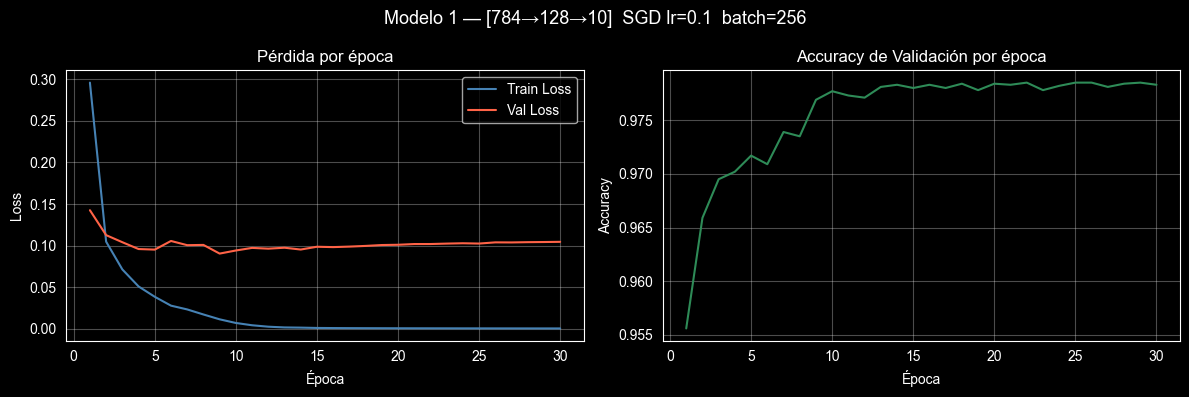

In [13]:
train_loader1 = DataLoader(train_ds, batch_size=256, shuffle=True,  num_workers=0)
val_loader    = DataLoader(val_ds,   batch_size=512, shuffle=False, num_workers=0)

model1 = MLP(784, [128], 10)
opt1   = optim.SGD(model1.parameters(), lr=0.1, momentum=0.9)
es1    = EarlyStopping(patience=5, delta=0.001)

print(f"Parámetros: {count_params(model1):,}")
print(model1)

h1 = train_model(model1, train_loader1, val_loader,
                 opt1, criterion, epochs=30, early_stopper=es1, name="Modelo1")
plot_history(h1, "Modelo 1 — [784→128→10]  SGD lr=0.1  batch=256")

Parámetros: 101,770
MLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


[Modelo1Adam] Época   1/30  Train Loss: 0.3943  Val Loss: 0.2395  Val Acc: 0.9316


[Modelo1Adam] Época   2/30  Train Loss: 0.1836  Val Loss: 0.1695  Val Acc: 0.9520


[Modelo1Adam] Época   3/30  Train Loss: 0.1304  Val Loss: 0.1373  Val Acc: 0.9610


[Modelo1Adam] Época   4/30  Train Loss: 0.1030  Val Loss: 0.1208  Val Acc: 0.9633


...

[Modelo1Adam] Época  26/30  Train Loss: 0.0023  Val Loss: 0.0978  Val Acc: 0.9769


[Modelo1Adam] Época  27/30  Train Loss: 0.0022  Val Loss: 0.0923  Val Acc: 0.9779


[Modelo1Adam] Época  28/30  Train Loss: 0.0045  Val Loss: 0.1402  Val Acc: 0.9676


[Modelo1Adam] Época  29/30  Train Loss: 0.0220  Val Loss: 0.1272  Val Acc: 0.9696


[Modelo1Adam] Época  30/30  Train Loss: 0.0111  Val Loss: 0.1258  Val Acc: 0.9734


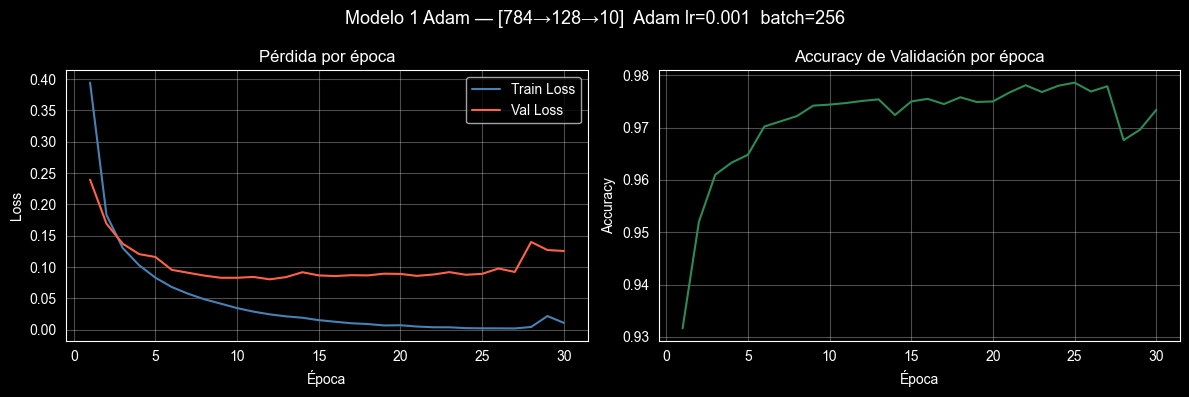

In [14]:
# exactamente mismo modeo con optimizador adam para ver si algo cambia
train_loader1Adam = DataLoader(train_ds, batch_size=256, shuffle=True,  num_workers=0)
val_loader = DataLoader(val_ds,   batch_size=512, shuffle=False, num_workers=0)

model1Adam = MLP(784, [128], 10)
opt1Adam = optim.Adam(model1Adam.parameters(), lr=0.001)
es1Adam = EarlyStopping(patience=5, delta=0.001)

print(f"Parámetros: {count_params(model1Adam):,}")
print(model1Adam)

h1Adam = train_model(model1Adam, train_loader1Adam, val_loader,
                     opt1Adam, criterion, epochs=30, early_stopper=es1Adam, name="Modelo1Adam")
plot_history(h1Adam, "Modelo 1 Adam — [784→128→10]  Adam lr=0.001  batch=256")

Parámetros: 235,146
MLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


[Modelo2] Época   1/30  Train Loss: 0.2978  Val Loss: 0.1594  Val Acc: 0.9541


[Modelo2] Época   2/30  Train Loss: 0.1163  Val Loss: 0.1028  Val Acc: 0.9691


[Modelo2] Época   3/30  Train Loss: 0.0776  Val Loss: 0.0990  Val Acc: 0.9682


[Modelo2] Época   4/30  Train Loss: 0.0545  Val Loss: 0.0843  Val Acc: 0.9757


...

[Modelo2] Época  26/30  Train Loss: 0.0087  Val Loss: 0.1188  Val Acc: 0.9797


[Modelo2] Época  27/30  Train Loss: 0.0048  Val Loss: 0.1392  Val Acc: 0.9777


[Modelo2] Época  28/30  Train Loss: 0.0045  Val Loss: 0.1361  Val Acc: 0.9785


[Modelo2] Época  29/30  Train Loss: 0.0138  Val Loss: 0.1396  Val Acc: 0.9760


[Modelo2] Época  30/30  Train Loss: 0.0085  Val Loss: 0.1167  Val Acc: 0.9788


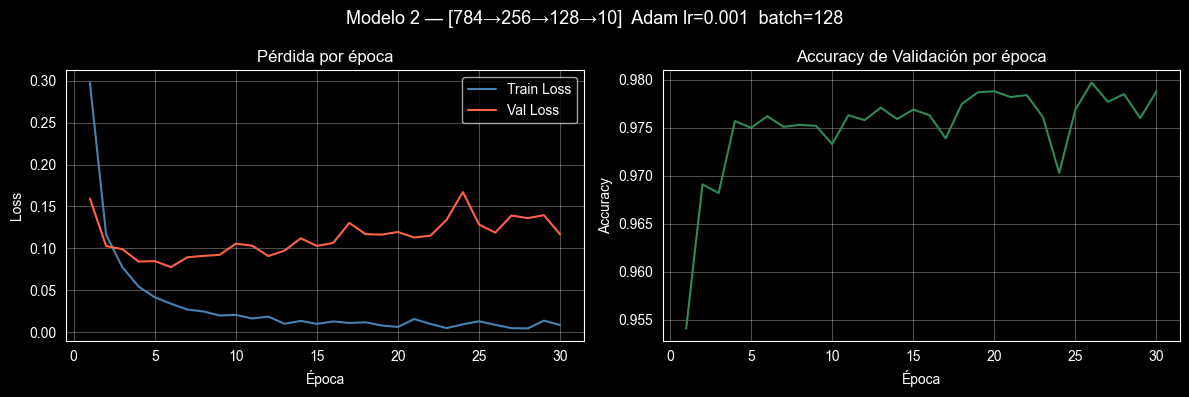

In [15]:
train_loader2 = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=0)

model2 = MLP(784, [256, 128], 10)
opt2   = optim.Adam(model2.parameters(), lr=0.001)
es2    = EarlyStopping(patience=5, delta=0.001)

print(f"Parámetros: {count_params(model2):,}")
print(model2)

h2 = train_model(model2, train_loader2, val_loader,
                 opt2, criterion, epochs=30, early_stopper=es2, name="Modelo2")
plot_history(h2, "Modelo 2 — [784→256→128→10]  Adam lr=0.001  batch=128")

Parámetros: 575,050
MLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)


[Modelo3] Época   1/40  Train Loss: 0.3163  Val Loss: 0.1319  Val Acc: 0.9601


[Modelo3] Época   2/40  Train Loss: 0.1115  Val Loss: 0.1041  Val Acc: 0.9665


[Modelo3] Época   3/40  Train Loss: 0.0768  Val Loss: 0.1011  Val Acc: 0.9678


[Modelo3] Época   4/40  Train Loss: 0.0594  Val Loss: 0.0874  Val Acc: 0.9736


...

[Modelo3] Época  36/40  Train Loss: 0.0061  Val Loss: 0.1206  Val Acc: 0.9818


[Modelo3] Época  37/40  Train Loss: 0.0061  Val Loss: 0.1374  Val Acc: 0.9795


[Modelo3] Época  38/40  Train Loss: 0.0059  Val Loss: 0.1155  Val Acc: 0.9816


[Modelo3] Época  39/40  Train Loss: 0.0059  Val Loss: 0.1227  Val Acc: 0.9776


[Modelo3] Época  40/40  Train Loss: 0.0053  Val Loss: 0.1169  Val Acc: 0.9802


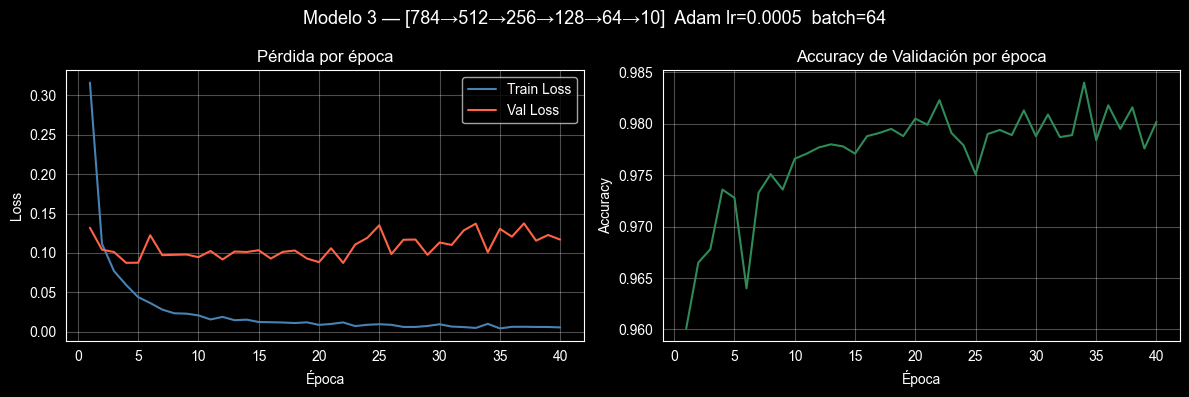

In [16]:
train_loader3 = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0)

model3 = MLP(784, [512, 256, 128, 64], 10)
opt3   = optim.Adam(model3.parameters(), lr=0.0005)
es3    = EarlyStopping(patience=5, delta=0.001)

print(f"Parámetros: {count_params(model3):,}")
print(model3)

h3 = train_model(model3, train_loader3, val_loader,
                 opt3, criterion, epochs=40, early_stopper=es3, name="Modelo3")
plot_history(h3, "Modelo 3 — [784→512→256→128→64→10]  Adam lr=0.0005  batch=64")

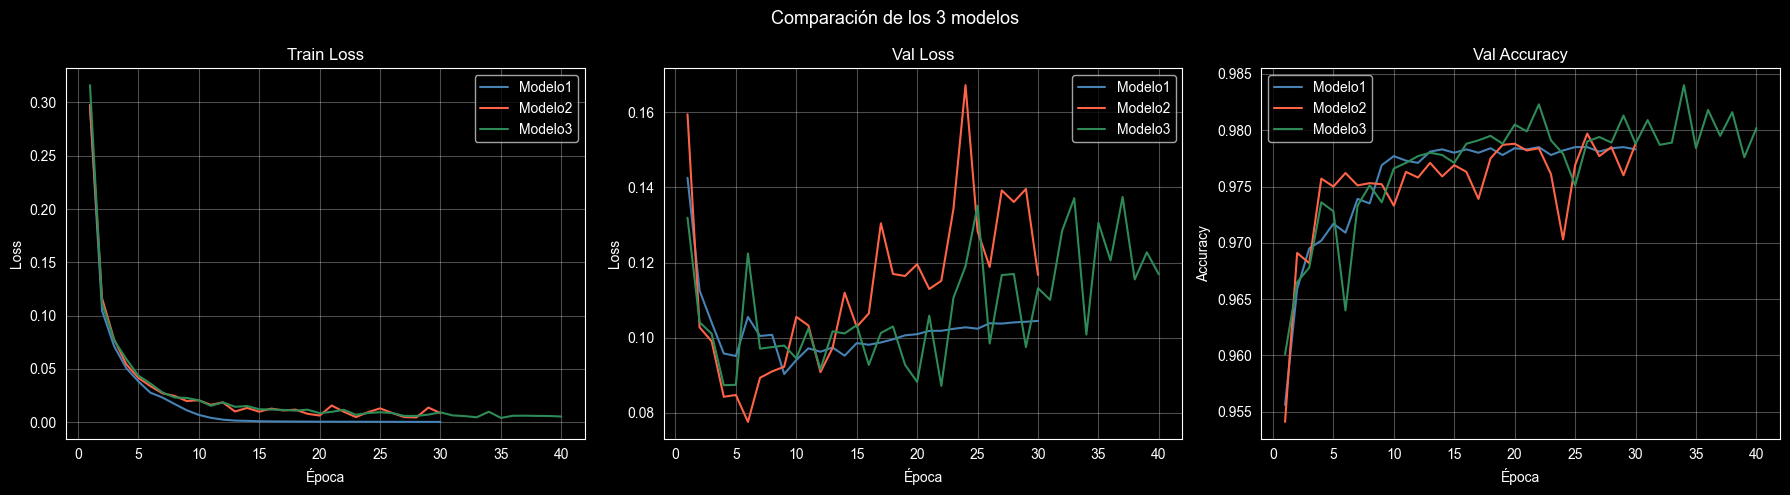


=== Mejor Val Accuracy por modelo ===
  Modelo1: 0.9785  (época 22)
  Modelo2: 0.9797  (época 26)
  Modelo3: 0.9840  (época 34)


In [17]:
# Graficas por IA
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
all_histories = [("Modelo1", h1), ("Modelo2", h2), ("Modelo3", h3)]
colors = ["steelblue", "tomato", "seagreen"]

for (name, h), c in zip(all_histories, colors):
    ep = range(1, len(h["val_loss"]) + 1)
    ax1.plot(ep, h["train_loss"], label=name, color=c)
    ax2.plot(ep, h["val_loss"],   label=name, color=c)
    ax3.plot(ep, h["val_acc"],    label=name, color=c)

ax1.set_title("Train Loss"); ax1.set_xlabel("Época"); ax1.set_ylabel("Loss")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.set_title("Val Loss"); ax2.set_xlabel("Época"); ax2.set_ylabel("Loss")
ax2.legend(); ax2.grid(True, alpha=0.3)

ax3.set_title("Val Accuracy"); ax3.set_xlabel("Época"); ax3.set_ylabel("Accuracy")
ax3.legend(); ax3.grid(True, alpha=0.3)

plt.suptitle("Comparación de los 3 modelos", fontsize=13)
plt.tight_layout()
plt.show()

print("\n=== Mejor Val Accuracy por modelo ===")
for name, h in all_histories:
    best = max(h["val_acc"])
    ep   = h["val_acc"].index(best) + 1
    print(f"  {name}: {best:.4f}  (época {ep})")

# Punto extra

In [19]:
model_map = {"Modelo1": model1, "Modelo2": model2, "Modelo3": model3}
best_name = max(all_histories, key=lambda t: max(t[1]["val_acc"]))[0]
best_model = model_map[best_name]
print(f"Mejor modelo: {best_name}")

test_loader = DataLoader(test_ds, batch_size=512, shuffle=False, num_workers=0)

best_model.eval()
test_loss_total, all_preds, all_labels = 0.0, [], []

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        logits = best_model(X)
        test_loss_total += criterion(logits, y).item() * len(X)
        all_preds.extend(logits.argmax(1).cpu().tolist())
        all_labels.extend(y.cpu().tolist())

test_loss = test_loss_total / len(test_loader.dataset)
test_acc  = np.mean(np.array(all_preds) == np.array(all_labels))

print(f"\n=== {best_name} en Test Set ===")
print(f"  Test Loss:     {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc:.4f}")

Mejor modelo: Modelo3

=== Modelo3 en Test Set ===
  Test Loss:     0.1024
  Test Accuracy: 0.9811


In [20]:
#mejor modelo
y_true = np.array(all_labels)
y_pred = np.array(all_preds)

cm = np.zeros((10, 10), dtype=int)
for t, p in zip(y_true, y_pred):
    cm[t, p] += 1

precision = np.zeros(10)
recall = np.zeros(10)
f1 = np.zeros(10)

for c in range(10):
    tp = cm[c, c]
    fp = cm[:, c].sum() - tp
    fn = cm[c, :].sum() - tp
    precision[c] = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall[c]    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    denom = precision[c] + recall[c]
    f1[c] = 2 * precision[c] * recall[c] / denom if denom > 0 else 0.0

accuracy_global = np.diag(cm).sum() / cm.sum()

print(f"{'Clase':>6}  {'Precision':>10}  {'Recall':>8}  {'F1-Score':>10}  {'Soporte':>8}")
print("-" * 52)
for c in range(10):
    print(f"{c:>6}  {precision[c]:>10.4f}  {recall[c]:>8.4f}  {f1[c]:>10.4f}  {cm[c].sum():>8}")
print("-" * 52)
print(f"\nAccuracy global: {accuracy_global:.4f}")

 Clase   Precision    Recall    F1-Score   Soporte
----------------------------------------------------
     0      0.9809    0.9959      0.9884       980
     1      0.9920    0.9877      0.9898      1135
     2      0.9844    0.9797      0.9820      1032
     3      0.9736    0.9842      0.9788      1010
     4      0.9907    0.9796      0.9852       982
     5      0.9886    0.9765      0.9825       892
     6      0.9833    0.9833      0.9833       958
     7      0.9850    0.9601      0.9724      1028
     8      0.9774    0.9754      0.9764       974
     9      0.9559    0.9881      0.9717      1009
----------------------------------------------------

Accuracy global: 0.9811


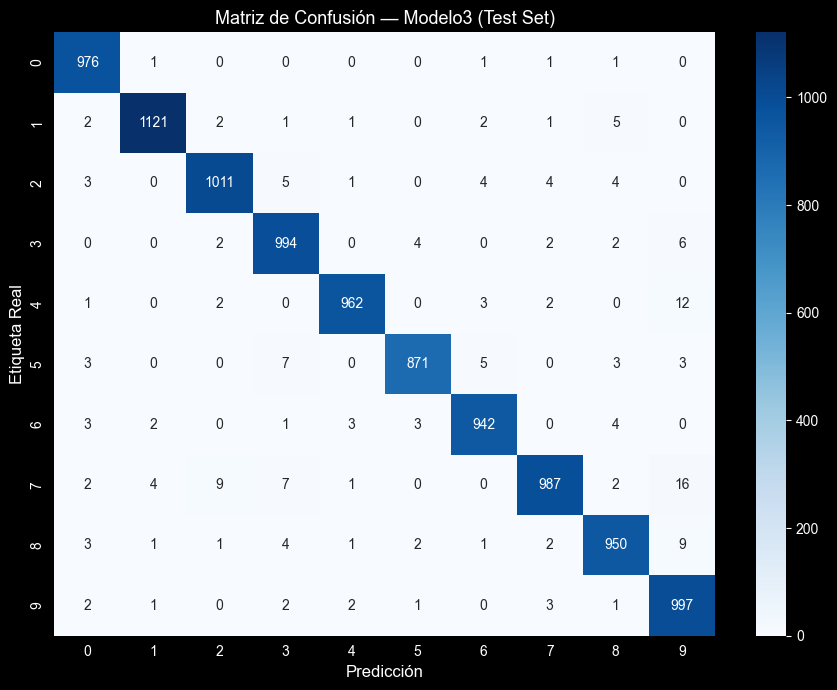

In [21]:
#matriz
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicción", fontsize=12)
plt.ylabel("Etiqueta Real", fontsize=12)
plt.title(f"Matriz de Confusión — {best_name} (Test Set)", fontsize=13)
plt.tight_layout()
plt.show()

# Reflexión Final


Esta actividad me parecio interesante por la diferencia que se vio comparandolo con el visto en clase que es mas tardado y de una manera mas limpia. Me gustó que se obligue a comparar diversos modelos para que se pueda ver la diferencia que causan pequeños cambios, como el mismo modelo usar SGd y adam. Igual implementar el early stopping y la clasificación sin libreria ayuodo a entender mas como funcionan las librerias.